# 03 - Desenho do Experimento (Teste A/B)

Objetivo: validar em produção se substituir a regra atual pela regra champion de priorização aumenta a chance de contato efetivo com o cidadão.

**Estimando causal principal:** efeito da regra champion sobre a proporção de CPFs elegíveis com pelo menos uma entrega (`delivered` ou `read`) entre os telefones selecionados. A métrica segue a mesma definição dos notebooks 01 e 02: `read` é considerado evidência de entrega porque é um estado posterior a `delivered`.

A unidade de randomização e de análise é o CPF. A população principal do teste são CPFs com 2 ou mais telefones móveis candidatos, pois são os casos em que o algoritmo de escolha altera a decisão operacional. O champion vem do notebook 02 e deve ser interpretado como candidato para teste, não como vencedor definitivo offline.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import confint_proportions_2indep, proportion_effectsize, proportions_ztest

import utils as u

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK')


Imports OK


## 1. Baseline histórico em CPFs elegíveis

O baseline do experimento deve representar apenas a população impactada pela regra de escolha: CPFs com pelo menos 2 telefones móveis candidatos. CPFs com 1 telefone continuam importantes para cobertura, mas não entram na análise principal porque não há decisão de ranking a validar.

Na base mascarada, o CPF da dimensão de telefone não casa diretamente com o CPF dos logs de disparo. Por isso, o baseline histórico usa uma proxy observável de elegibilidade: CPFs que já tiveram 2 ou mais telefones distintos nos disparos. A dimensão ainda é carregada para medir o tamanho potencial da população elegível no RMI.

**Nota sobre população elegível:** A população elegível para o experimento é restrita a CPFs com dois ou mais telefones candidatos, o que representa apenas uma pequena fração de todos os CPFs (~30.695 na dimensão RMI, dos quais ~10.411 tiveram disparos no período). Isso limita significativamente o volume diário disponível para o teste.

In [2]:
df_disparo, df_telefone = u.carregar_dados()
df_disparo = u.filtrar_status_invalidos(df_disparo)
df_telefone = u.filtrar_telefones_fixos(df_telefone)
df_disparo['envio_datahora'] = pd.to_datetime(df_disparo['envio_datahora'])

df_aparicoes_brutas = u.explodir_aparicoes(df_telefone)
df_phone_cpf_dim = u.preparar_telefone_cpf(df_aparicoes_brutas)
df_phone_cpf_dim['cpf_key_dim'] = df_phone_cpf_dim['cpf'].astype('string')

qtd_telefones_cpf_dim = df_phone_cpf_dim.groupby('cpf_key_dim')['telefone_numero'].nunique()
cpfs_elegiveis_dimensao = qtd_telefones_cpf_dim[qtd_telefones_cpf_dim >= 2].index

df_disparo_cpf = df_disparo.dropna(subset=['cpf']).copy()
df_disparo_cpf['cpf_key'] = df_disparo_cpf['cpf'].astype('string')
qtd_telefones_historico_cpf = df_disparo_cpf.groupby('cpf_key')['contato_telefone'].nunique()
cpfs_elegiveis_historico = qtd_telefones_historico_cpf[qtd_telefones_historico_cpf >= 2].index

metricas_cpf = u.preparar_metricas_cpf(df_disparo)
metricas_cpf['cpf_key'] = metricas_cpf['cpf'].astype('string')
metricas_cpf_elegiveis = metricas_cpf[metricas_cpf['cpf_key'].isin(cpfs_elegiveis_historico)].copy()

if metricas_cpf_elegiveis.empty:
    raise ValueError('Não há CPFs elegíveis com disparos históricos para estimar o baseline do experimento.')

taxa_entrega_cpf_baseline_elegivel = metricas_cpf_elegiveis['cpf_teve_entrega'].mean()
taxa_read_cpf_baseline_elegivel = metricas_cpf_elegiveis['cpf_teve_read'].mean()
taxa_falha_cpf_baseline_elegivel = metricas_cpf_elegiveis['cpf_teve_falha'].mean()

JANELA_RECENTE_DIAS = 28
data_fim = df_disparo['envio_datahora'].max()
data_inicio_recente = data_fim - pd.Timedelta(days=JANELA_RECENTE_DIAS)
df_disparo_recente = df_disparo[df_disparo['envio_datahora'] >= data_inicio_recente].copy()
df_disparo_cpf_recente = df_disparo_recente.dropna(subset=['cpf']).copy()
df_disparo_cpf_recente['cpf_key'] = df_disparo_cpf_recente['cpf'].astype('string')
qtd_telefones_recente_cpf = df_disparo_cpf_recente.groupby('cpf_key')['contato_telefone'].nunique()
cpfs_elegiveis_recente = qtd_telefones_recente_cpf[qtd_telefones_recente_cpf >= 2].index
metricas_cpf_recente = u.preparar_metricas_cpf(df_disparo_recente)
metricas_cpf_recente['cpf_key'] = metricas_cpf_recente['cpf'].astype('string')
metricas_cpf_recente_elegiveis = metricas_cpf_recente[metricas_cpf_recente['cpf_key'].isin(cpfs_elegiveis_recente)].copy()

if metricas_cpf_recente_elegiveis.empty:
    taxa_entrega_cpf_referencia = taxa_entrega_cpf_baseline_elegivel
    taxa_read_cpf_referencia = taxa_read_cpf_baseline_elegivel
    taxa_falha_cpf_referencia = taxa_falha_cpf_baseline_elegivel
    baseline_referencia = 'historico_completo'
else:
    taxa_entrega_cpf_referencia = metricas_cpf_recente_elegiveis['cpf_teve_entrega'].mean()
    taxa_read_cpf_referencia = metricas_cpf_recente_elegiveis['cpf_teve_read'].mean()
    taxa_falha_cpf_referencia = metricas_cpf_recente_elegiveis['cpf_teve_falha'].mean()
    baseline_referencia = f'janela_recente_{JANELA_RECENTE_DIAS}_dias'

dias = max((df_disparo['envio_datahora'].max() - df_disparo['envio_datahora'].min()).days, 1)
cpfs_historicos_com_disparo = metricas_cpf['cpf_key'].nunique()
cpfs_elegiveis_com_disparo = metricas_cpf_elegiveis['cpf_key'].nunique()
cpfs_elegiveis_recente_com_disparo = metricas_cpf_recente_elegiveis['cpf_key'].nunique()
cpfs_elegiveis_por_dia_historico = cpfs_elegiveis_com_disparo / dias
cpfs_elegiveis_por_dia_recente = cpfs_elegiveis_recente_com_disparo / JANELA_RECENTE_DIAS
cpfs_elegiveis_por_dia = cpfs_elegiveis_por_dia_recente if cpfs_elegiveis_por_dia_recente > 0 else cpfs_elegiveis_por_dia_historico
cobertura_elegivel_historica = cpfs_elegiveis_com_disparo / cpfs_historicos_com_disparo

caminho_resumo_priorizacao = u.PROCESSED_DIR / 'resumo_modelo_priorizacao.pkl'
if caminho_resumo_priorizacao.exists():
    with open(caminho_resumo_priorizacao, 'rb') as f:
        resumo_modelo_priorizacao = pickle.load(f)
else:
    resumo_modelo_priorizacao = {}

CHAMPION_METODO = resumo_modelo_priorizacao.get('champion_metodo', 'champion_notebook_02')
CHAMPION_MOTIVO = resumo_modelo_priorizacao.get('champion_motivo', 'Executar o notebook 02 para materializar o champion escolhido.')

display(pd.DataFrame([{
    'cpfs_historicos_com_disparo': cpfs_historicos_com_disparo,
    'cpfs_elegiveis_dimensao_rmi': len(cpfs_elegiveis_dimensao),
    'cpfs_elegiveis_com_disparo': cpfs_elegiveis_com_disparo,
    'cobertura_elegivel_historica': cobertura_elegivel_historica,
    'criterio_elegibilidade_baseline': 'dois ou mais telefones distintos observados nos logs por CPF',
    'taxa_entrega_cpf_baseline_elegivel': taxa_entrega_cpf_baseline_elegivel,
    'taxa_read_cpf_baseline_elegivel': taxa_read_cpf_baseline_elegivel,
    'taxa_falha_cpf_baseline_elegivel': taxa_falha_cpf_baseline_elegivel,
    'baseline_referencia_amostra': baseline_referencia,
    'taxa_entrega_cpf_referencia': taxa_entrega_cpf_referencia,
    'taxa_read_cpf_referencia': taxa_read_cpf_referencia,
    'taxa_falha_cpf_referencia': taxa_falha_cpf_referencia,
    'periodo_dias': dias,
    'janela_recente_dias': JANELA_RECENTE_DIAS,
    'cpfs_elegiveis_recente_com_disparo': cpfs_elegiveis_recente_com_disparo,
    'cpfs_elegiveis_por_dia_historico': cpfs_elegiveis_por_dia_historico,
    'cpfs_elegiveis_por_dia_recente': cpfs_elegiveis_por_dia_recente,
    'cpfs_elegiveis_por_dia_estimado': cpfs_elegiveis_por_dia,
    'champion_metodo': CHAMPION_METODO,
}]))

print('Motivo do champion:', CHAMPION_MOTIVO)


Filtrando status intermediários: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,281 (-8)
Telefones únicos: 283,281
Aparições brutas: 1,522,742
Sistemas únicos: 6
Pares telefone-CPF candidatos: 1,246,889


,cpfs_historicos_com_disparo,cpfs_elegiveis_dimensao_rmi,cpfs_elegiveis_com_disparo,cobertura_elegivel_historica,criterio_elegibilidade_baseline,taxa_entrega_cpf_baseline_elegivel,taxa_read_cpf_baseline_elegivel,taxa_falha_cpf_baseline_elegivel,baseline_referencia_amostra,taxa_entrega_cpf_referencia,taxa_read_cpf_referencia,taxa_falha_cpf_referencia,periodo_dias,janela_recente_dias,cpfs_elegiveis_recente_com_disparo,cpfs_elegiveis_por_dia_historico,cpfs_elegiveis_por_dia_recente,cpfs_elegiveis_por_dia_estimado,champion_metodo
0,267116,30695,10411,0.038976,dois ou mais telefones distintos observados no...,0.964653,0.834598,0.422054,janela_recente_28_dias,0.959288,0.806616,0.422392,227,28,393,45.863436,14.035714,14.035714,fonte_mais_recente


Motivo do champion: Modelo não superou os baselines determinísticos; escolhido melhor método determinístico não aleatório. Cobertura de holdout inferior a 50%, reforcando necessidade de A/B.


## 2. Hipóteses e métricas

| Item | Definição |
|---|---|
| H0 | A regra champion não aumenta a proporção de CPFs elegíveis com pelo menos uma entrega. |
| H1 | A regra champion aumenta a proporção de CPFs elegíveis com pelo menos uma entrega. |
| Métrica primária | CPF elegível teve pelo menos uma entrega (`delivered` ou `read`). |
| Secundárias | CPF teve pelo menos um `read`, taxa de falha por CPF, custo por entrega, cobertura elegível e taxa por telefone enviado. |
| Guardrails | Bloqueios/spam, incidentes de API, desequilíbrio por `categoria_hsm`, DDD, quantidade de telefones, múltiplos proprietários e CPFs distintos por telefone. |


## 3. Mecânica do teste

- Randomização por CPF, persistente por hash, nunca por telefone.
- Divisão 50/50 entre controle e tratamento.
- Estratificar por `categoria_hsm`, DDD e faixa de quantidade de telefones candidatos quando operacionalmente possível.
- Controle: regra atual real e congelada antes do teste. Se ela não estiver formalizada, executar uma fase curta de shadow logging/A-A para documentar a política atual antes do A/B.
- Tratamento: `CHAMPION_METODO` produzido pelo notebook 02.
- Ambos os grupos escolhem 2 telefones por CPF elegível, preservando comparabilidade de custo.
- Excluir CPFs com menos de 2 telefones candidatos da análise principal; reportá-los em análise separada de cobertura.


## 4. Tamanho amostral


In [3]:
p1 = taxa_entrega_cpf_referencia
uplifts = [0.005, 0.01, 0.02, 0.03]
alpha = 0.05
power = 0.80

resultados_tamanho = []
for uplift in uplifts:
    p2 = min(p1 + uplift, 0.99)
    effect_size = proportion_effectsize(p2, p1)
    n_por_grupo = zt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, ratio=1, alternative='larger')
    n_total = int(np.ceil(n_por_grupo * 2))
    resultados_tamanho.append({
        'uplift_pp': uplift * 100,
        'p1_entrega_cpf_referencia': p1,
        'baseline_referencia': baseline_referencia,
        'p2_tratamento': p2,
        'n_por_grupo': int(np.ceil(n_por_grupo)),
        'n_total_cpfs': n_total,
        'dias_necessarios': int(np.ceil(n_total / cpfs_elegiveis_por_dia)) if cpfs_elegiveis_por_dia > 0 else None,
    })

df_tamanho = pd.DataFrame(resultados_tamanho)
display(df_tamanho)


,uplift_pp,p1_entrega_cpf_referencia,baseline_referencia,p2_tratamento,n_por_grupo,n_total_cpfs,dias_necessarios
0,0.5,0.959288,janela_recente_28_dias,0.964288,18159,36318,2588
1,1.0,0.959288,janela_recente_28_dias,0.969288,4238,8476,604
2,2.0,0.959288,janela_recente_28_dias,0.979288,896,1792,128
3,3.0,0.959288,janela_recente_28_dias,0.989288,313,625,45


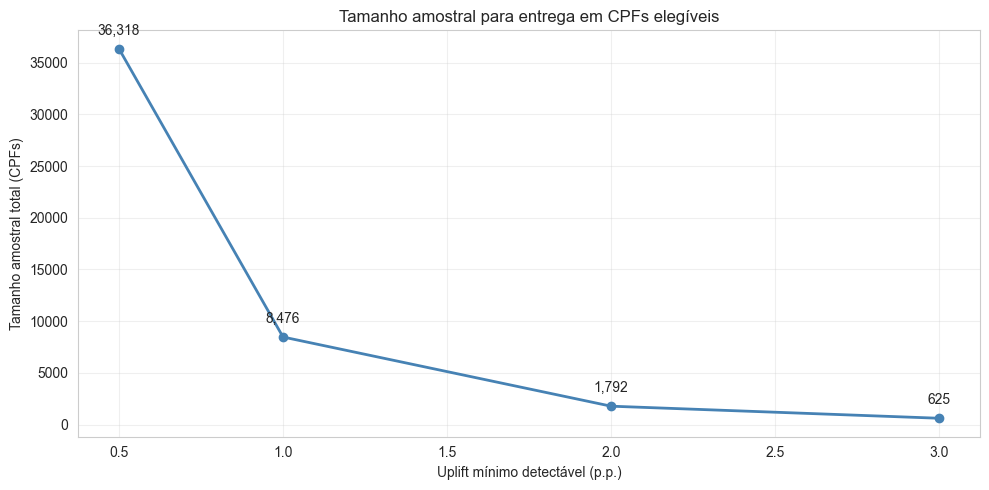

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_tamanho['uplift_pp'], df_tamanho['n_total_cpfs'], marker='o', color='steelblue', linewidth=2)
for _, row in df_tamanho.iterrows():
    ax.annotate(f"{int(row['n_total_cpfs']):,}", (row['uplift_pp'], row['n_total_cpfs']), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xlabel('Uplift mínimo detectável (p.p.)')
ax.set_ylabel('Tamanho amostral total (CPFs)')
ax.set_title('Tamanho amostral para entrega em CPFs elegíveis')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Duração estimada e análise


In [5]:
print('Duração estimada do teste A/B')
for _, row in df_tamanho.iterrows():
    dias_teste = row['dias_necessarios']
    semanas = dias_teste / 7 if dias_teste else None
    print(f"Uplift de {row['uplift_pp']:.1f} p.p.: {int(row['n_total_cpfs']):,} CPFs elegíveis -> ~{dias_teste} dias ({semanas:.1f} semanas)")

print('\nRecomendação: executar por no mínimo 14 dias para capturar efeitos de dia da semana, mesmo se o tamanho amostral for atingido antes.')


Duração estimada do teste A/B
Uplift de 0.5 p.p.: 36,318 CPFs elegíveis -> ~2588 dias (369.7 semanas)
Uplift de 1.0 p.p.: 8,476 CPFs elegíveis -> ~604 dias (86.3 semanas)
Uplift de 2.0 p.p.: 1,792 CPFs elegíveis -> ~128 dias (18.3 semanas)
Uplift de 3.0 p.p.: 625 CPFs elegíveis -> ~45 dias (6.4 semanas)

Recomendação: executar por no mínimo 14 dias para capturar efeitos de dia da semana, mesmo se o tamanho amostral for atingido antes.


In [6]:
print('Código de análise após o teste:')
print('entrega_controle = ...')
print('total_controle = ...')
print('entrega_tratamento = ...')
print('total_tratamento = ...')
print('successes = [entrega_controle, entrega_tratamento]')
print('samples = [total_controle, total_tratamento]')
print('z_stat, p_value = proportions_ztest(successes, samples, alternative="smaller")')
print('ci_low, ci_high = confint_proportions_2indep(entrega_tratamento, total_tratamento, entrega_controle, total_controle, method="newcomb")')

entrega_controle = 4200
total_controle = 5000
entrega_tratamento = 4300
total_tratamento = 5000
successes = [entrega_controle, entrega_tratamento]
samples = [total_controle, total_tratamento]
z_stat, p_value = proportions_ztest(successes, samples, alternative='smaller')
ci_low, ci_high = confint_proportions_2indep(
    entrega_tratamento, total_tratamento,
    entrega_controle, total_controle,
    method='newcomb',
)

taxa_controle = entrega_controle / total_controle
taxa_tratamento = entrega_tratamento / total_tratamento
diferenca_absoluta = taxa_tratamento - taxa_controle
lift_relativo = diferenca_absoluta / taxa_controle

print('\nDemonstracao hipotetica')
print('Controle:', f'{entrega_controle}/{total_controle} = {taxa_controle:.2%}')
print('Tratamento:', f'{entrega_tratamento}/{total_tratamento} = {taxa_tratamento:.2%}')
print('Diferenca absoluta:', f'{diferenca_absoluta:.2%}')
print('Lift relativo:', f'{lift_relativo:.2%}')
print('IC 95% da diferenca tratamento-controle:', f'[{ci_low:.2%}, {ci_high:.2%}]')
print('Z-statistic:', f'{z_stat:.4f}')
print('P-value:', f'{p_value:.4f}')


Código de análise após o teste:
entrega_controle = ...
total_controle = ...
entrega_tratamento = ...
total_tratamento = ...
successes = [entrega_controle, entrega_tratamento]
samples = [total_controle, total_tratamento]
z_stat, p_value = proportions_ztest(successes, samples, alternative="smaller")
ci_low, ci_high = confint_proportions_2indep(entrega_tratamento, total_tratamento, entrega_controle, total_controle, method="newcomb")

Demonstracao hipotetica
Controle: 4200/5000 = 84.00%
Tratamento: 4300/5000 = 86.00%
Diferenca absoluta: 2.00%
Lift relativo: 2.38%
IC 95% da diferenca tratamento-controle: [0.60%, 3.40%]
Z-statistic: -2.8006
P-value: 0.0026


## 6. Plano de análise e critérios de decisão

- Análise principal por intention-to-treat: cada CPF conta no grupo sorteado, mesmo se algum envio falhar operacionalmente.
- Teste estatístico: z-test unilateral para duas proporções, avaliando se tratamento > controle na métrica primária de entrega por CPF elegível.
- Reportar diferença absoluta, intervalo de confiança de 95% por Newcombe, lift relativo, leitura por CPF, falha por CPF e custo por entrega.
- Análises de sensibilidade: remover janelas com incidente de API e estratificar o resultado por `categoria_hsm`, DDD, faixa de quantidade de telefones, múltiplos proprietários e CPFs distintos por telefone.
- Critério de implantação: ganho estatisticamente significativo na métrica primária, sem piora relevante nos guardrails.
- Critério de iteração: ganho positivo mas inconclusivo, ou ganho concentrado em subgrupos que exija nova regra.
- Critério não substituir: ausência de ganho, piora operacional relevante ou risco elevado de contato com destinatário errado.

## 7. Riscos e mitigações

| Risco | Mitigação |
|---|---|
| Contaminação por telefone compartilhado | Randomizar por CPF e monitorar a sobreposição de telefones entre grupos. |
| Atraso de status (`delivered`/`read`) | Fechar a janela de mensuração somente após prazo operacional suficiente para estabilizar status, por exemplo 24-48h após o disparo. |
| Sazonalidade e mix de campanhas | Executar por pelo menos duas semanas, estratificar por `categoria_hsm` e controlar por dia da semana. |
| Controle mal definido | Fixar e documentar a regra controle antes do teste. |
| CPFs com menos de 2 telefones | Excluir da análise principal e reportar cobertura. |
| Incidentes de API ou fornecedor | Marcar janelas afetadas e executar análise de sensibilidade sem esses períodos. |
| Custo desigual entre grupos | Garantir que controle e tratamento selecionem 2 telefones por CPF elegível. |
| Destinatário errado | Monitorar telefones com muitos proprietários, muitos CPFs distintos e pioras por esses segmentos como guardrail. |


---
### Pontos de Atenção

- **Duração impraticável para efeitos pequenos:** Para detectar 0,5 p.p. de uplift, seriam necessários ~2.588 dias (~7 anos). Mesmo 1 p.p. exige ~604 dias (cerca de 1 ano e 8 meses). Isso implica que o efeito esperado é muito pequeno para ser detectado em tempo hábil, a menos que seja possível aumentar o volume elegível.
- **População elegível restrita:** Apenas ~30.695 CPFs na dimensão RMI têm dois ou mais telefones, e apenas ~10.411 tiveram disparos no período (~3,9% dos CPFs com histórico). O volume diário estimado é de apenas ~14 CPFs elegíveis/dia.
- **Baseline alto:** A taxa de entrega para CPFs elegíveis é ~96%, o que limita quanto uplift é possível. Se 96% dos CPFs já têm entrega bem-sucedida, o ganho marginal é pequeno.
- **Recomendação prática:** Considerar uma métrica de negócio mais discriminativa, como custo por mensagem efetivamente lida ou taxa de leitura em vez de entrega, e ampliar a população elegível via integração de mais fontes de dados.

## 8. Artefato do experimento


In [7]:
u.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
parametros_experimento = {
    'baseline_entrega_cpf_elegivel': taxa_entrega_cpf_baseline_elegivel,
    'baseline_read_cpf_elegivel': taxa_read_cpf_baseline_elegivel,
    'baseline_falha_cpf_elegivel': taxa_falha_cpf_baseline_elegivel,
    'baseline_referencia_amostra': baseline_referencia,
    'baseline_entrega_cpf_referencia': taxa_entrega_cpf_referencia,
    'baseline_read_cpf_referencia': taxa_read_cpf_referencia,
    'baseline_falha_cpf_referencia': taxa_falha_cpf_referencia,
    'janela_recente_dias': JANELA_RECENTE_DIAS,
    'cpfs_historicos_com_disparo': int(cpfs_historicos_com_disparo),
    'cpfs_elegiveis_dimensao_rmi': int(len(cpfs_elegiveis_dimensao)),
    'cpfs_elegiveis_historico_com_disparo': int(cpfs_elegiveis_com_disparo),
    'cpfs_elegiveis_recente_com_disparo': int(cpfs_elegiveis_recente_com_disparo),
    'criterio_elegibilidade_baseline': 'dois ou mais telefones distintos observados nos logs por CPF',
    'cobertura_elegivel_historica': float(cobertura_elegivel_historica),
    'tamanhos_amostrais': df_tamanho.to_dict('records'),
    'alpha': alpha,
    'power': power,
    'alternative': 'tratamento_maior_que_controle',
    'unidade_randomizacao': 'cpf',
    'populacao_principal': 'cpfs_com_2_ou_mais_telefones_moveis_candidatos',
    'metrica_primaria': 'cpf_teve_ao_menos_uma_entrega',
    'metricas_secundarias': ['cpf_teve_ao_menos_um_read', 'taxa_falha_por_cpf', 'custo_por_entrega', 'cobertura_elegivel', 'taxa_por_telefone_enviado'],
    'guardrails_segmentos': ['categoria_hsm', 'DDD', 'quantidade_telefones', 'multiplos_proprietarios', 'cpfs_distintos_por_telefone'],
    'tratamento': CHAMPION_METODO,
    'tratamento_motivo': CHAMPION_MOTIVO,
    'controle': 'regra_atual_real_congelada; se não formalizada, executar shadow_logging/A-A antes do A/B',
    'volume_diario_cpfs_elegiveis': cpfs_elegiveis_por_dia,
    'volume_diario_cpfs_elegiveis_historico': cpfs_elegiveis_por_dia_historico,
    'volume_diario_cpfs_elegiveis_recente': cpfs_elegiveis_por_dia_recente,
}
with open(u.PROCESSED_DIR / 'parametros_experimento.pkl', 'wb') as f:
    pickle.dump(parametros_experimento, f)
print('Parametros do experimento salvos em:', u.PROCESSED_DIR / 'parametros_experimento.pkl')


Parametros do experimento salvos em: C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\parametros_experimento.pkl


---
## O que foi trabalhado aqui?

Este notebook fecha a solução mudando o padrão de evidência. Os notebooks anteriores constroem uma regra candidata com base em histórico observado, mas histórico não prova causalmente que a regra nova será melhor em produção. O objetivo aqui é desenhar o experimento que poderia validar, com randomização, se o champion realmente melhora o contato com o cidadão.

A unidade escolhida para randomização e análise é o CPF. Essa escolha evita contaminação entre telefones do mesmo cidadão: se telefones de um mesmo CPF fossem distribuídos entre controle e tratamento, os grupos deixariam de representar políticas concorrentes de escolha. A população principal também é restrita a CPFs com dois ou mais telefones candidatos, porque apenas nesses casos existe uma decisão de priorização a ser testada.

A métrica primária é a proporção de CPFs elegíveis com pelo menos uma entrega (`delivered` ou `read`) entre os telefones selecionados. Essa métrica traduz o objetivo operacional de reduzir desperdício e aumentar o contato efetivo. Métricas secundárias e guardrails entram para proteger a interpretação: leitura, falha, custo por entrega, incidentes de API, desequilíbrio por categoria, DDD e risco de telefone compartilhado.

O cálculo de tamanho amostral mostra a principal restrição de negócio. Como o baseline de entrega já é alto e o volume diário de CPFs elegíveis é baixo, detectar ganhos pequenos exigiria uma duração impraticável. Isso é uma conclusão relevante: ela indica que a validação por A/B é possível apenas para efeitos relativamente grandes ou com expansão da população elegível.

O desenho proposto, portanto, posiciona a solução com cautela: o champion `fonte_mais_recente` é uma regra simples, explicável e pronta para teste, mas não deve ser implantada como vencedora definitiva sem experimento. Se o objetivo operacional for detectar ganhos menores ou gerar impacto mais rápido, a recomendação natural é revisar a métrica primária para algo mais sensível, como leitura ou custo por mensagem lida, e ampliar o universo elegível com mais fontes ou critérios de candidatura.

Em conjunto, os quatro notebooks formam uma cadeia lógica completa: primeiro validam a estrutura dos dados, depois medem a confiabilidade das fontes, em seguida transformam esses sinais em uma regra de escolha top-2 e, por fim, definem como essa regra deve ser validada causalmente antes de virar política de produção.